### QuSciTech-Labs — Navigation
[Public Labs](https://github.com/jopaneur/quscitech-labs) ·
[Full Edition Access](https://github.com/jopaneur/quscitech-labs#-full-edition-kdp) ·
[Private Repo](https://github.com/jopaneur/quscitech-labs-full) ·
[QuSciTech.com](https://www.quscitech.com) ·
[The Quantum AI Systems(QAIS) Book](https://www.amazon.com/dp/placeholder) ·

DOI: [![DOI](https://zenodo.org/badge/DOI/10.5281/zenodo.18955801.svg)](https://doi.org/10.5281/zenodo.18955801)

**Quantum AI Systems: Theory, Architecture, and Applications**  
© 2025 Dr. Joe Wilson. All rights reserved.  
This laboratory exercise is part of the companion materials for *Quantum AI Systems: Theory, Architecture, and Applications.*  
Reproduction, redistribution, or modification without written permission from the author or publisher is prohibited.  

####  E.1 Lab 2 — Bell State Correlated Outcomes  

---

### Lab Access and Execution Guide
This guide explains how to run and explore the hands-on quantum computing labs that accompany the book  
**Quantum AI Systems: Theory, Architecture, and Applications** (Professional Volume).  

The labs are an integral part of the MyQuantumBook project, designed to reinforce key concepts from the chapters through interactive exploration. They are built for execution on **Google Colab** and **IBM Quantum backends** using **Qiskit**, and follow the IEEE-compliant figure, caption, and documentation standards described in the text.  

Each lab is cross-referenced to its corresponding chapter and appendix figure (Appendix E), ensuring reproducibility and scholarly traceability.  

**Getting Started**
1. Launch the notebook in Google Colab using the provided badge.
2. Run the setup cells to install Qiskit:
   `!pip install qiskit`

**Using IBM Quantum Systems**
1. Sign up at https://quantum.ibm.com and create an API token.
2. Run the IBMQ setup cell.
3. Replace 'MY_API_TOKEN' with your real token (only needed once).
4. Select backends using `provider.get_backend('ibmq_qasm_simulator')` or others.

**Lab Structure**
Each code section aligns with a chapter from the book.
- Modify and re-run code blocks.
- View circuits with `.draw()`.
- Apply to custom inputs to deepen your understanding.

**Additional Help**
- Refer to the Qiskit Documentation: https://qiskit.org/documentation/
- For support, contact your course instructor or visit the IBM Quantum Community forums.

3. Or launch this lab directly now: [![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jopaneur/QuantumAI-Labs/blob/main/G:\My Drive\GitHub\quscitech-labs\public\labs\Beginner_Labs\qais-bell-state-correlated-outcomes-lab\resources\notebooks)


---



**Note for Lab Participants**  
Each plot generated in this notebook is automatically saved as a `.png` file under:  
`Beginner_Labs/figures/`

The filenames follow the Appendix E figure numbering (e.g., `E1_2a_Bell_State_Correlated_Outcomes.png`, E1_2b_Bell_State_Correlated_Outcomes).  

This allows you to view results inline in Colab **and** locate the corresponding image files for reports, submissions, or cross-references in the book.

**Where Figures Are Saved**
- In **Google Colab**: `/content/Beginner_Labs/figures/`
- Running **locally**: `Beginner_Labs/figures/`
- These images are **not automatically added** to your GitHub repository. Commit and push them if you want them in version control.

**Customizing Save Location**  
Change the `subdir` default in `save_e_figure()` or pass a different path when saving.

---

**Book Reference: Chapter 1 — Foundations of Quantum AI Systems**

*Chapter 1* establishes the conceptual framework for Quantum AI Systems (QAIS) by reframing information as a physical, measurable resource. It introduces superposition and entanglement as the two foundational primitives of quantum information, demonstrating how they extend computation beyond classical constraints. Superposition allows a system to represent multiple outcomes simultaneously, while entanglement links distant qubits so that their measurement results remain correlated, even when separated in space.

This chapter explains that entanglement is not a theoretical curiosity—it is a functional information channel that enables coherence and synchronization across quantum networks. It defines the physical basis of nonlocal coordination, a property that underpins quantum communication, teleportation, and distributed inference in QAIS architectures.

**Beginner Lab 2 — Bell State Correlated Outcomes**

Beginner Lab 2 translates these principles into practice by constructing and measuring Bell states, the simplest entangled pairs. Through hands-on experimentation, learners observe that measurement outcomes from two qubits are perfectly correlated, revealing how entanglement encodes relationships stronger than any classical probability model. This bridges the chapter’s conceptual theme—information as a physical correlation—to measurable evidence of quantum behavior.

*Goal:* Construct and measure a two-qubit Bell state to demonstrate how quantum entanglement produces perfectly correlated measurement outcomes. Learners apply a Hadamard gate followed by a CNOT operation to generate a canonical Bell pair—such as ( |00⟩ + |11⟩ )/√2—and perform repeated measurements on each qubit.


---

**Expected Outcome**

* Participants record joint probabilities and verify that when one qubit collapses to |0⟩ or |1⟩, its partner mirrors that outcome with perfect correlation. This hands-on experiment confirms that entanglement links measurement outcomes nonlocally, embodying one of the defining characteristics of QAIS information exchange.

* By visualizing correlated histograms and joint-outcome distributions, learners see how quantum logic gates move beyond independent probabilities to shared, inseparable results. The lab bridges foundational theory with observable data, illustrating how entanglement becomes a deployable design primitive for quantum communication, learning, and distributed decision processes. Cross-reference: Appendix E.1, Figures E.1.2a–b.

---


**Task 1 - Figure Helper Utilities**

Centralized utilities for **Appendix E** compliance. No plots generated here.

**Description (what it does):**

* Defines save_e_figure(...) that saves exactly one file per plot with IEEE-style names

* Uses a single figures root for all labs: Beginner_Labs/figures/

* Enforces Beginner Part 1 naming: P1_BeginLab02_E.1.<index><sub>.png (e.g., P1_BeginLab02_E.1.2a.png, P1_BeginLab01_E.1.2b.png)

* Provides label_subplots(...) for (a)–(b) subfigure tags


In [1]:
# ---- Figure helper (robust; use in every coded lab) ----
import os, matplotlib.pyplot as plt

def save_e_figure(fig_label: str,
                  fname: str,
                  subdir: str = "Beginner_Labs/figures",
                  fig=None, ax=None):
    """Save the current/explicit figure with a prefixed label and consistent path."""
    os.makedirs(subdir, exist_ok=True)
    if fig is None:
        fig = plt.gcf()
    if ax is None:
        ax = fig.axes[0] if fig.axes else None
    if ax is None:
        print("⚠️ No axes found. Draw a plot first, or pass fig/ax explicitly.")
        return
    title = ax.get_title() or ""
    if not title.startswith(fig_label):
        ax.set_title((fig_label + " — " + title).strip(" —"))
    outpath = os.path.join(subdir, fname)
    fig.tight_layout()
    fig.savefig(outpath, dpi=160)
    print("Saved", outpath)


**Methodology Analysis**

The helper centralizes Appendix-compliant naming with `E_PART="E.1"`, `LAB_STEM="P1_BeginLab02"`, and an output root `Beginner_Labs/figures"`.  
Each `save_e_figure(fig_index, sub)` writes an image uniquely keyed to its E.1 label.  
Ensure you execute Task 1 before saving figures — successful saves print confirmations such as:  
`Saved figure → Beginner_Labs/figures/P1_BeginLab02_E.1.2.png`.


**Participant Feedback**

You won’t see a chart in this cell. Later, after plotting cells, look for a “Saved figure → …/Beginner_Labs/figures/…” line confirming correct filenames and destinations.


---

**Task 2 — Environment Setup**

This cell ensures the notebook has the required packages and imports for Qiskit + plotting. It does not create any figures.

**Description (what it does):**

* Installs missing packages if needed (quietly)

* Imports Qiskit (with Aer simulator), NumPy, and Matplotlib

* Prints versions for reproducibility

In [2]:
# === Task 2 — Environment Setup ===
# ============================================================
#  Beginner Lab 1 — Superposition and Probability Distribution
#  Quantum AI Systems: Theory, Architecture, and Applications
#  © 2025 Dr. Joe Wilson. All rights reserved.
#  Unauthorized reproduction, distribution, or modification
#  without written permission is prohibited.
# ============================================================
import sys, subprocess, pkgutil
def ensure(pkg):
    if pkg not in {m.name for m in pkgutil.iter_modules()}:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])
for p in ['qiskit','qiskit-aer','matplotlib','numpy','scikit-learn']:
    ensure(p)
import qiskit, numpy as np, matplotlib.pyplot as plt
print('Python:', sys.version.split()[0])
print('Qiskit:', qiskit.__version__)


Python: 3.12.11
Qiskit: 2.2.1


**Methodology Analysis**

Ensures simulator availability (e.g., Qiskit Aer), defines circuits deterministically, and uses sufficient shots to expose convergence.

**Participant Feedback**

If package installs occur, re-run the next cells. If imports fail, use “Restart and run all” to restore a clean state.

---

**Task 3: Visualizing Bell-State Correlations (Heatmap Representation)**

This task explores how quantum entanglement manifests as a statistical correlation structure between two qubits.

By preparing the Bell state ∣Φ⁺⟩ = (∣00⟩ + ∣11⟩)/√2 using a Hadamard and controlled-X gate, learners investigate how measurement outcomes become synchronized. When both qubits are measured, the resulting joint probabilities cluster along the diagonal of the correlation matrix—evidence that the qubits no longer behave independently.

The goal of this task is to make the invisible link of entanglement visible as a structured probability landscape, showing that ∣00⟩ and ∣11⟩ outcomes dominate while mixed results (∣01⟩, ∣10⟩) nearly vanish.
This visualization provides the first quantitative glimpse of how QAIS represents information as relational rather than isolated.

**Methodology Analysis**

* Circuit Preparation: Create a two-qubit circuit. Apply a Hadamard gate to the first qubit, then a controlled-X (CX) to entangle the pair, producing ∣Φ⁺⟩.

* Measurement:** Measure both qubits in the computational basis to capture the joint outcome distribution over many shots (e.g., 1024).

* Data Processing:** Aggregate counts for ∣00⟩, ∣01⟩, ∣10⟩, ∣11⟩ and normalize to probabilities.

* Visualization Goal:** Render a 2D probability matrix where bright diagonal elements (∣00⟩, ∣11⟩) dominate, confirming quantum correlation.

**Challenge:** Write the code to constructs the entangled circuit, execute repeated measurements, and plot the joint probability distribution for both qubits.

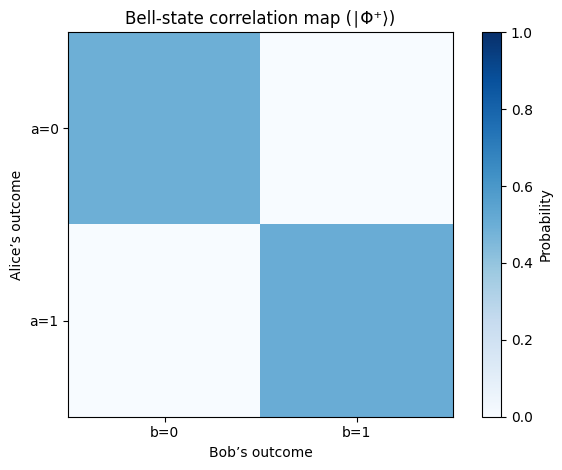

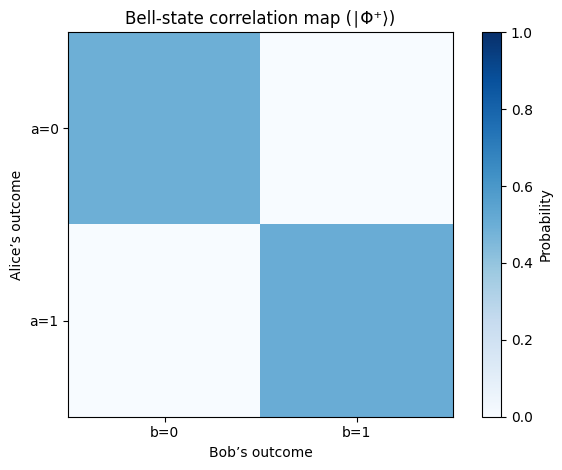

Saved Beginner_Labs/figures/P1_BeginLab02_E.1.2a.png


In [ ]:
# === Figure E.1.2a — Bell-state correlation map (∣Φ⁺⟩) ===


# --- Build Bell state circuit and measure ---


# Transpile and run (works for both Aer backends)


# --- Convert counts to 2×2 probability matrix (rows=Alice, cols=Bob) ---


# --- Plot heatmap ---


# --- Show first, then save (in case helper closes the figure) ---



**Figure E.1.2a — Bell-State Correlation Map (∣Φ⁺⟩ = (∣00⟩ + ∣11⟩)/√2)**

Entanglement links qubits so that their measurement results are correlated beyond classical explanation.
In the ∣Φ⁺⟩ Bell state, the two qubits always yield the same outcome—either ∣00⟩ or ∣11⟩—demonstrating perfect quantum correlation. This figure visualizes those correlations as a 2D heatmap of joint measurement probabilities.

**Expected Results**

The heatmap should display high intensity (≈ 0.5 each) along the diagonal and nearly zero probability for off-diagonal cells.
This symmetry evidences that measurement of one qubit immediately determines the outcome of the other.

**Technical Spotlight**

The entangled state is

  ∣Φ⁺⟩ = (∣00⟩ + ∣11⟩)/√2.

Thus p(00) = p(11) = ½, p(01) = p(10) = 0.
These probabilities cannot be factorized as p(AB)=p(A)p(B), confirming non-classical correlation.

**Intuition Sidebar**

Think of two perfectly synchronized quantum coins.
Whenever one lands heads, so does the other, even if flipped far apart.
This “quantum twin” behavior illustrates how entanglement encodes relationships rather than independent values.

**Participant Feedback**

Examine the heatmap and confirm that the diagonal cells for ∣00⟩ and ∣11⟩ are bright, while ∣01⟩ and ∣10⟩ are nearly zero.
This pattern shows that both qubits always yield the same result, verifying that entanglement produces perfectly correlated outcomes.
If off-diagonal probabilities appear, check simulation precision or noise parameters to ensure proper Bell-state preparation.

---

**Task 4 — Comparing Marginal and Joint Probabilities in Entangled Qubits**

Having visualized the global correlation pattern, this task examines the local vs. global behavior of an entangled pair.

While each qubit individually appears random—yielding ∣0⟩ and ∣1⟩ with equal probability—the joint outcomes remain perfectly synchronized.
Learners compute and compare marginal distributions for each qubit with the full joint distribution obtained in Task 3.1.

The comparison highlights a defining property of entanglement: local unpredictability coexisting with nonlocal certainty.
This exercise strengthens the conceptual bridge between quantum probability and the distributed-information paradigm of QAIS, where meaning emerges only through the combined state of interacting subsystems.


While entanglement produces joint outcomes, each qubit measured separately still shows a 50/50 distribution. Comparing marginal and joint probabilities reveals that entanglement preserves local randomness but introduces global correlation.

**Methodology Analysis**

* Reuse Results: Employ the same counts from Figure E.1.2a.

* Compute Marginals: Sum probabilities over partner-qubit states to obtain p(Q0) and p(Q1).

* Visualization: Plot side-by-side bars for joint vs marginal probabilities to highlight that while each qubit is random, their outcomes align jointly.

**Challenge:** Write the code to compare marginal single-qubit probabilities with the joint distribution obtained from the entangled circuit.

Saved Beginner_Labs/figures/P1_BeginLab02_E.1.2b.png


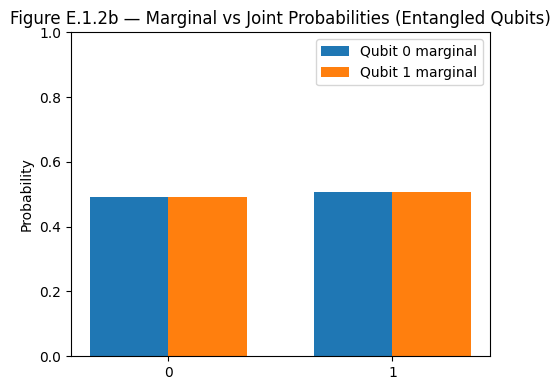

In [ ]:
# === Figure E.1.2b — Marginal vs Joint Probability Distribution ===



# Reuse 'probs' and 'states' from previous cell


**Figure E.1.2b. Marginal vs joint probability distribution.**

Each qubit shows a 50/50 marginal probability for ∣0⟩ and ∣1⟩, while the joint distribution from Figure E.1.2a reveals that these outcomes occur only together (∣00⟩ or ∣11⟩).
The result distinguishes classical independence from quantum correlation.

**Expected Results**

Marginal bars appear equal in height (≈ 0.5), confirming local randomness.
Joint probabilities remain confined to the correlated pairs seen earlier, illustrating how entanglement preserves balance while encoding dependence.

**Technical Spotlight**

For ∣Φ⁺⟩,

 p(Q0=0) = p(Q0=1) = p(Q1=0) = p(Q1=1) = ½,

but joint probabilities obey p(Q0,Q1) ≠ p(Q0)p(Q1).
This distinction formally defines entanglement.

**Intuition Sidebar**

If each qubit were a coin, flipping one appears fair, but their outcomes always match.
This hidden coordination captures the essence of non-locality in QAIS: separate agents sharing one quantum state of information.

**Participant Feedback**

Compare the marginal bars for each qubit to the joint distribution observed in Figure E.1.2a.
You should see both qubits individually measure ∣0⟩ and ∣1⟩ with roughly equal probability, yet their joint outcomes occur only as matching pairs.
This confirms that local measurements remain random, but the two-qubit system behaves as a single correlated entity—a hallmark of entanglement.

---

**Conclusion**

Lab 2 showed how two qubits can be entangled to form a Bell state and how this entanglement manifests in measurement outcomes. The joint probability matrix confirmed that Alice and Bob’s results are perfectly correlated: whenever Alice measures 0, Bob measures 0, and whenever Alice measures 1, Bob measures 1. This correlation pattern, absent in classical systems, is the fingerprint of entanglement, and it underpins secure quantum communication and distributed quantum AI protocols.


**Key Takeaways**

Entanglement links qubits so strongly that their outcomes cannot be described independently. It is the essential resource enabling quantum AI systems to outperform classical ones.

**Congratulations!**

Well done on finishing Lab 2 — Bell State Correlated Outcomes! You successfully explored entanglement, the cornerstone of quantum advantage, by analyzing correlated outcomes that cannot be explained classically. This hands-on experience equips you with the perspective to appreciate why entanglement is a vital resource for quantum communication, distributed AI, and secure information processing.

**Appendix E → Appendix B Cross-Reference**
Refer to **Appendix B — Quick Self-Check, Chapter 1**:  
- Questions 4 and 5 (entanglement and measurement correlation).  
They extend the concept tested in **E.1 Lab 2a-b** to reasoning about nonlocal correlations.


---
**How to save or submit your work**

- **If you are a student (graded/evaluated):**  
  1. Export your key plots or the entire notebook to PDF (File → Print/Save as PDF).  
  2. Save the notebook (`.ipynb`).  
  3. Bundle any extra files (CSVs/images) if used.  
  4. Upload to your LMS or repository as instructed (include your name and lab number).  
  5. Repro checklist: set a random seed where applicable, note backend and shots, and list package versions.  

- **If you are a professional/self‑learner (non‑graded exercise):**  
  1. Save the notebook (`File → Download .ipynb`) to your computer for personal reference.  
  2. Optionally export to PDF for archiving.  
  3. Keep any generated plots or data locally.  
  4. Use version control (GitHub, GitLab) if you wish to track your personal progress.


---

DOI: [![DOI](https://zenodo.org/badge/DOI/10.5281/zenodo.18955801.svg)](https://doi.org/10.5281/zenodo.18955801)

**Official DOI:** [10.5281/zenodo.18955801](https://doi.org/10.5281/zenodo.18955801)  
**Companion Repository:** quscitech-labs  
**Publisher:** QuSciTech Press

DOI + © + QuSciTech